In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
import sweetviz as sv
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **CFPB Consumer Complaints - Product: Credit Reporting**

Objective: profile the full cleaned dataset, surface dominant complaint patterns, and document key geography-based differences that motivate the time-series analysis in notebooks 03-04.

In [3]:
# Loading the cleaned full dataset
df = pd.read_parquet(r"..\data\complaints_cleaned.parquet")

print(f"Loaded {len(df):,} rows & {len(df.columns)} columns:")

df.head(3)

Loaded 12,835,673 rows & 20 columns:


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID,year_quarter,region
0,2020-07-13,Mortgage,FHA mortgage,Trouble during payment process,None,"I currently have my mortgage with GMFS, servic...",None,"SAMC Honebee TRS, LLC",AL,36695,None,Consent provided,Web,2020-07-13,Closed with explanation,Yes,None,3743391,2020Q3,South
1,2023-12-16,Credit reporting,Credit reporting,Incorrect information on your report,Information belongs to someone else,None,None,"FactorTrust, Inc.",NY,13224,None,Consent not provided,Web,2023-12-16,Closed with explanation,Yes,None,8011171,2023Q4,Northeast
2,2024-01-27,Credit reporting,Credit reporting,Incorrect information on your report,Account information incorrect,None,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",NY,11714,None,Consent not provided,Web,2024-01-27,Closed with non-monetary relief,Yes,None,8236394,2024Q1,Northeast


The full cleaned dataset loaded properly. Next, we will take only the subset related to Credit reporting.

# Step 1: Creating Sub-Dataset for the Project - Credit Reporting

In [4]:
# Filter dataset to only include credit reporting related complaints for subsequent analysis
df_cr = df[df["Product"] == "Credit reporting"]

# Verify unique values after taking the credit reporting subset
print(f"Unique product values after taking the credit reporting subset containing {df_cr.shape[0]:,} records: {df_cr['Product'].unique()}")

Unique product values after taking the credit reporting subset containing 10,033,301 records: ['Credit reporting']


# Step 2: Creating Stratified Sample for EDA - Credit Reporting

## Step 2.1: Creating Strata

Given the large size of the Credit Reporting subset, we will create a sample retaining the proportion of the key strata: time-frequency and geographical-frequency.

In [5]:
df_cr['stratum'] = (
    df_cr['year_quarter'].astype(str) + "|" +
    df_cr['region'].astype(str)
)

## Step 2.2: Checking Stratum Granularity

A quick cardinality check confirms that product-time-region strata remain informative without becoming too sparse for exploratory diagnostics and downstream subset design.

In [6]:
num_unique_strata = df_cr['stratum'].nunique()
print(f"Total number of unique strata: {num_unique_strata:,}")

Total number of unique strata: 265


In [7]:
strata_counts = df_cr.groupby(['year_quarter', 'region']).size()

strata_counts.describe()

count       265.000000
mean      37861.513208
std      104062.061415
min          11.000000
25%        1156.000000
50%        4683.000000
75%       22289.000000
max      917786.000000
dtype: float64

Interpretation:
- The median stratum size is large enough to preserve meaningful product-time-region structure.
- The distribution remains right-skewed, which is expected in CFPB data because complaint activity is concentrated in a subset of product-time-region combinations.
- A limited long tail of small strata is acceptable for descriptive diagnostics, especially since the downstream workflow ultimately narrows to the credit card subset.

In [8]:
print(f"Number of strata with fewer than 20 samples: {(strata_counts < 20).sum():,} out of {num_unique_strata:,} (i.e., {((strata_counts < 20).sum()/num_unique_strata):.1}%).")

Number of strata with fewer than 20 samples: 1 out of 265 (i.e., 0.004%).


Conclusion: the product-time-region structure is sufficiently coherent for feature engineering and downstream subset design.

## Step 2.3: Creating Stratified Sample

In [10]:
# Step 2.3: Create a 500k stratified sample from df_cr (stratified by year_quarter x region)
target_n = 500_000
random_state = 42

if len(df_cr) <= target_n:
    df_cr_sample500k = df_cr.sample(frac=1, random_state=random_state).reset_index(drop=True)
else:
    strata_sizes = df_cr.groupby("stratum", observed=True).size().rename("N")
    total_n = int(strata_sizes.sum())

    # Proportional target allocation with largest-remainder correction so total == target_n
    exact_alloc = (strata_sizes / total_n) * target_n
    base_alloc = np.floor(exact_alloc).astype(int)
    remainder = exact_alloc - base_alloc

    shortfall = target_n - int(base_alloc.sum())
    if shortfall > 0:
        top_remainder_strata = remainder.sort_values(ascending=False).index[:shortfall]
        base_alloc.loc[top_remainder_strata] += 1

    alloc = base_alloc.clip(upper=strata_sizes)

    sampled_parts = []
    for stratum_name, n_take in alloc.items():
        if n_take <= 0:
            continue
        sampled_parts.append(
            df_cr[df_cr["stratum"] == stratum_name].sample(n=int(n_take), random_state=random_state)
        )

    df_cr_sample500k = (
        pd.concat(sampled_parts, axis=0)
          .sample(frac=1, random_state=random_state)
          .reset_index(drop=True)
    )

print(f"df_cr shape: {df_cr.shape}")
print(f"df_cr_sample500k shape: {df_cr_sample500k.shape}")
print("\nSample stratum distribution check (top 10):")
print(df_cr_sample500k["stratum"].value_counts().head(10))

df_cr shape: (10033301, 21)
df_cr_sample500k shape: (500000, 21)

Sample stratum distribution check (top 10):
stratum
2025Q4|South        45737
2025Q3|South        39094
2025Q2|South        32061
2025Q1|South        28545
2024Q4|South        21451
2024Q3|South        17890
2024Q2|South        14003
2025Q4|West         10724
2024Q1|South        10574
2025Q4|Northeast     9836
Name: count, dtype: int64


In [17]:
# Check the proportion of the quarters and regions in the sample vs full credit reporting dataset
# Show proportion of quarters in df_cr and df_cr_sample500k side by side for comparison
quarter_dist_cr = df_cr['year_quarter'].value_counts(normalize=True).sort_index()
quarter_dist_sample = df_cr_sample500k['year_quarter'].value_counts(normalize=True).sort_index()
quarter_comparison = pd.DataFrame({
    'Full Credit Reporting': quarter_dist_cr,
    'Sample 500k': quarter_dist_sample
}).fillna(0)
print("Quarter distribution comparison:")
print(quarter_comparison)
# Show proportion of regions in df_cr and df_cr_sample500k side by side for comparison
region_dist_cr = df_cr['region'].value_counts(normalize=True).sort_index()
region_dist_sample = df_cr_sample500k['region'].value_counts(normalize=True).sort_index()
region_comparison = pd.DataFrame({
    'Full Credit Reporting': region_dist_cr,
    'Sample 500k': region_dist_sample
}).fillna(0)
print("Region distribution comparison:")
print(region_comparison)

Quarter distribution comparison:
              Full Credit Reporting  Sample 500k
year_quarter                                    
2012Q4                     0.000187     0.000186
2013Q1                     0.000306     0.000306
2013Q2                     0.000346     0.000346
2013Q3                     0.000394     0.000396
2013Q4                     0.000387     0.000388
2014Q1                     0.000746     0.000746
2014Q2                     0.000729     0.000730
2014Q3                     0.000778     0.000778
2014Q4                     0.000661     0.000662
2015Q1                     0.000786     0.000786
2015Q2                     0.000803     0.000802
2015Q3                     0.000997     0.000996
2015Q4                     0.000830     0.000832
2016Q1                     0.000981     0.000980
2016Q2                     0.001145     0.001144
2016Q3                     0.001192     0.001190
2016Q4                     0.001075     0.001076
2017Q1                     0.001279 

Therefore, the sample generated properly stratified.

In [ ]:
# Take a parquet outpot of dr_cr_sample500k for later use
df_cr_sample500k.to_parquet(r"..\data\processed\credit_reporting_sample_500k.parquet", index=False)

# Step 3. Global EDA Profiling - Credit Reporting

This section uses automated profiling outputs to summarize dataset structure, dominant categories, and potential quality signals before segment-level comparisons.

In [18]:
profile = ProfileReport(
    df_cr_sample500k,
    title="CFPB Credit Reporting Complaints - YData Profiling Report",
    explorative=True  # richer, but still reasonable runtime
)

profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 21/21 [19:26<00:00, 55.57s/it]t]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [19]:
# Save YData profiling report for the Credit Reporting subset
profile.to_file("../reports/cfpb_credit_reporting_ydata_profile.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 1.1 Key Univariate Insights

The profiling report indicates a complaint mix dominated by Credit reporting, with concentration in a small number of high-volume issue types and firms.

Summary highlights:
- Product concentration is high, with Credit reporting as the dominant class.
- Issue distribution is skewed toward a few recurring categories (notably incorrect-information themes).
- Response timeliness is high overall, though minor segment differences remain important for operational interpretation.
- Date distribution is right-skewed, reflecting recent complaint growth.

These patterns justify segment-aware analysis and motivate explicit South vs Others comparisons in the next subsection.

## 1.2 South vs Others Segment Comparison

Given the project focus on regional heterogeneity, this section compares South against all other regions to identify differences in complaint composition and operational response characteristics.

In [ ]:
# South vs rest split for regional comparison using Credit Reporting subset
south_df = df_cr[df_cr['region'] == 'South'].copy()
other_df = df_cr[df_cr['region'] != 'South'].copy()

In [ ]:
# Generate comparison report
sweet_report = sv.compare([south_df, "South"], [other_df, "Others"])

                                             |          | [  0%]   00:00 -> (? left)


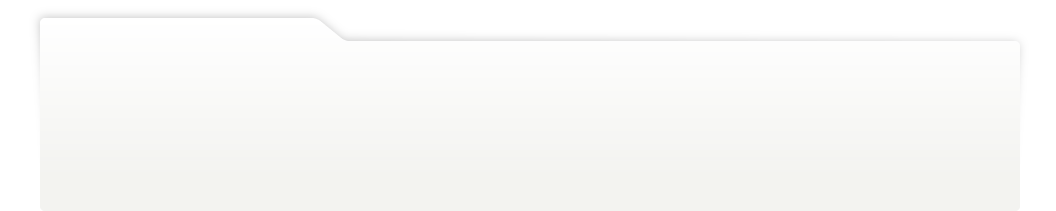
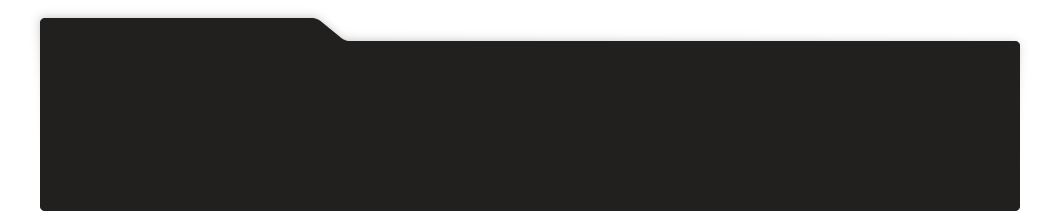
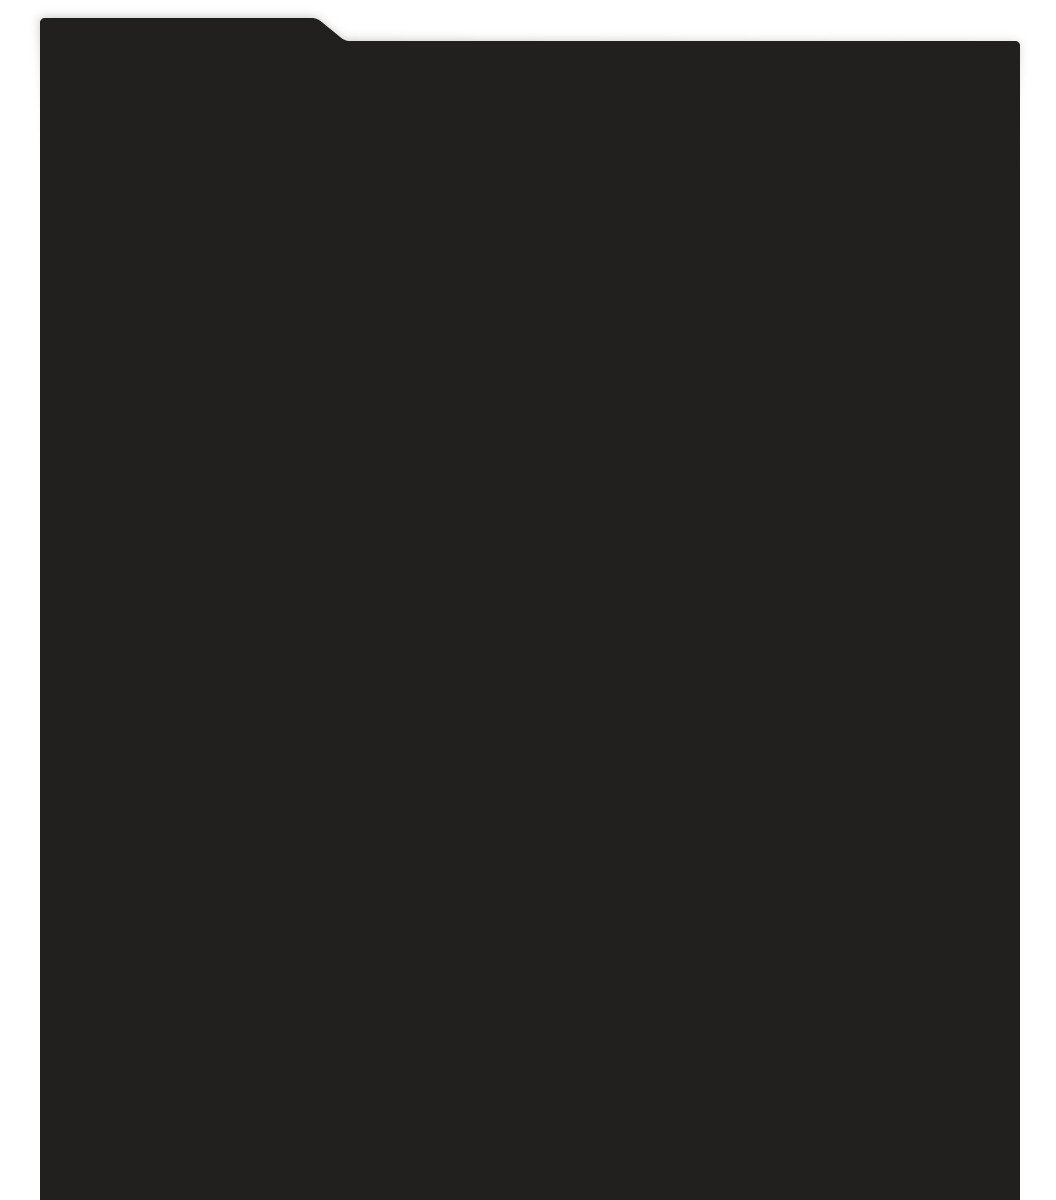
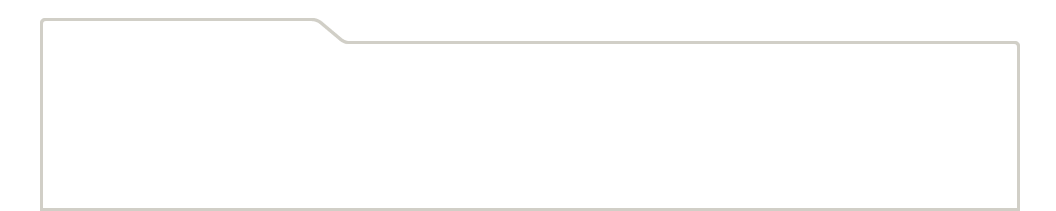
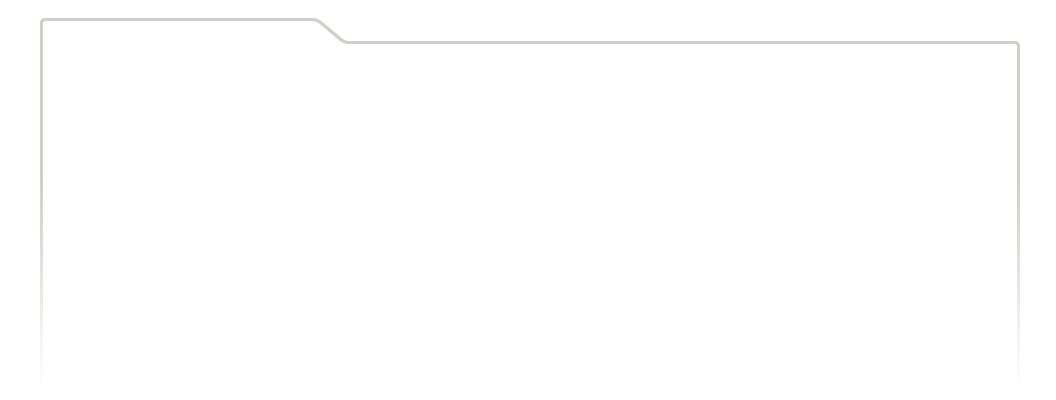
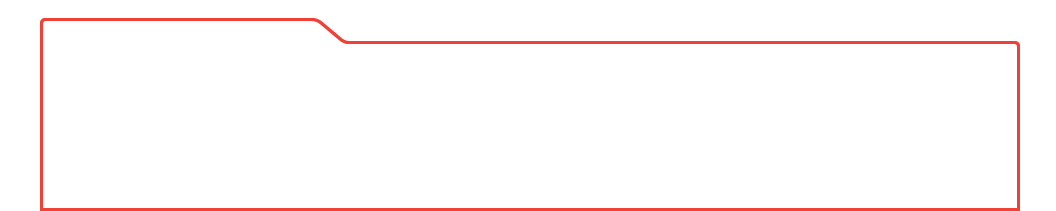
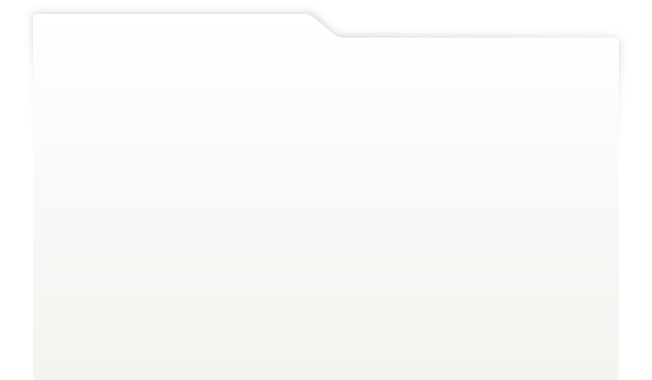
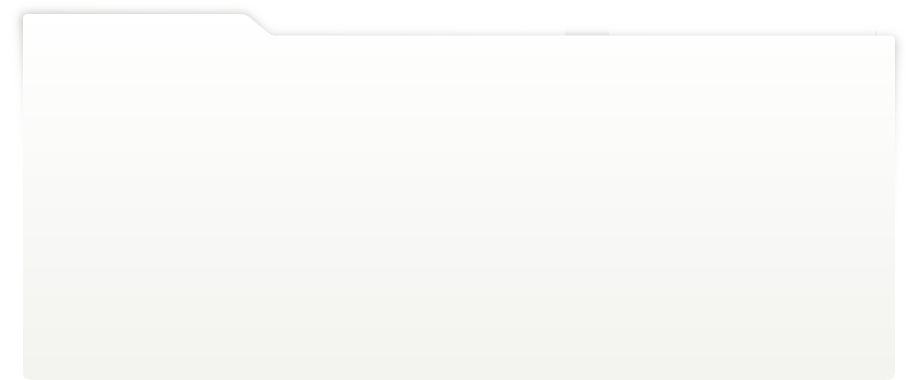
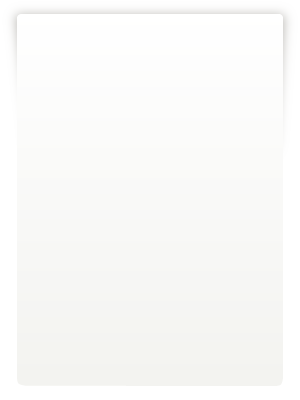
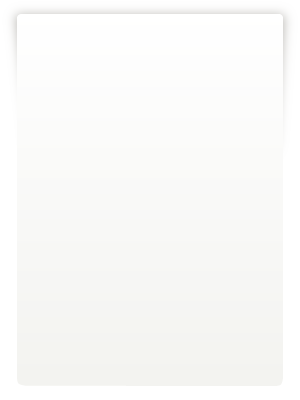
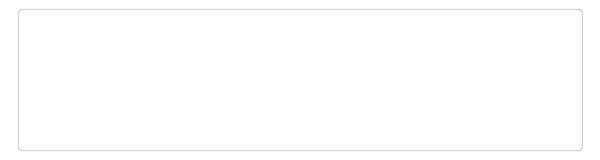
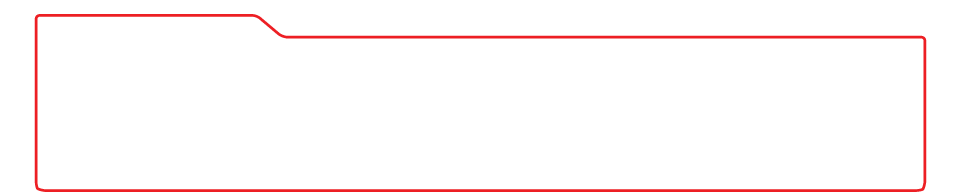
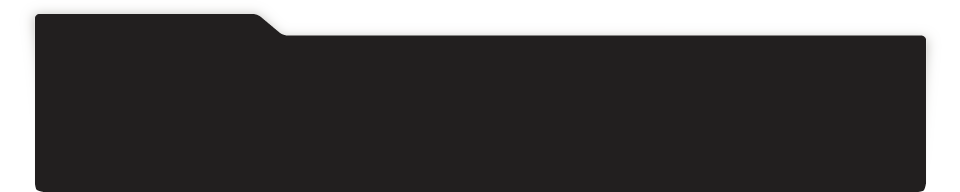
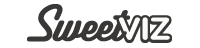
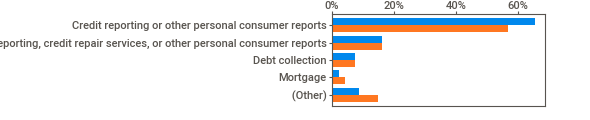
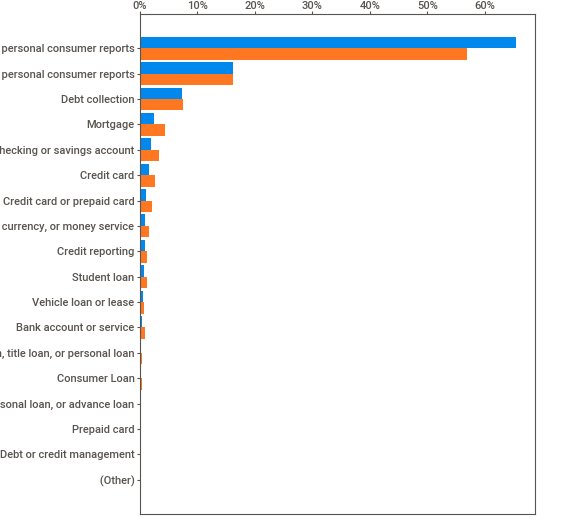
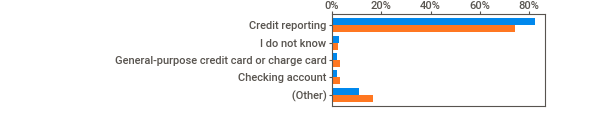
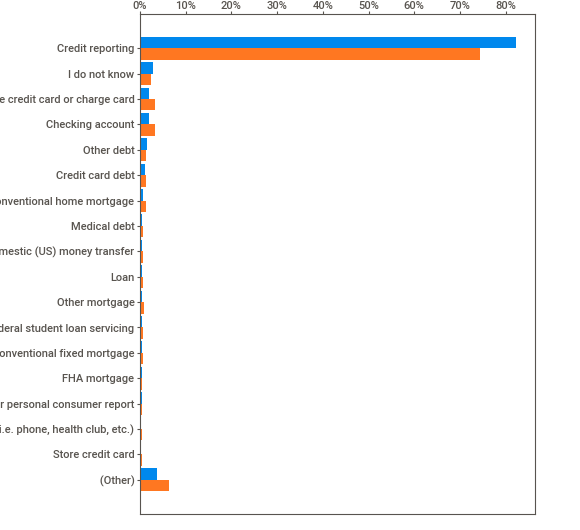
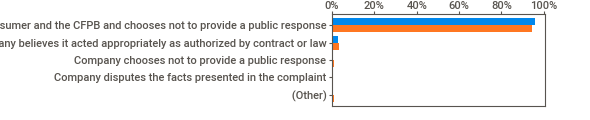
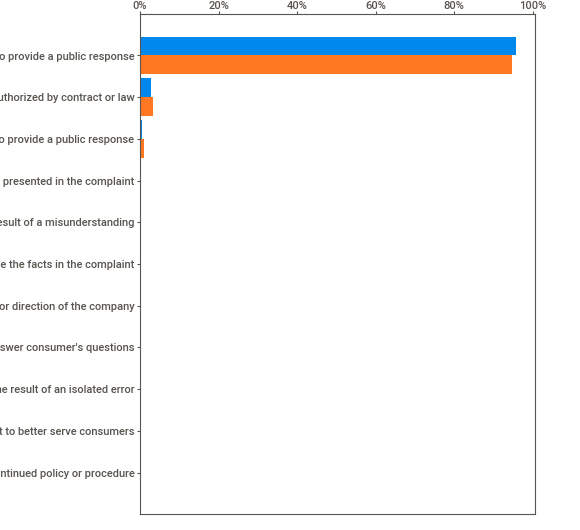
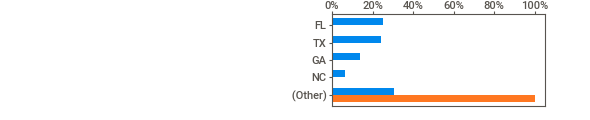
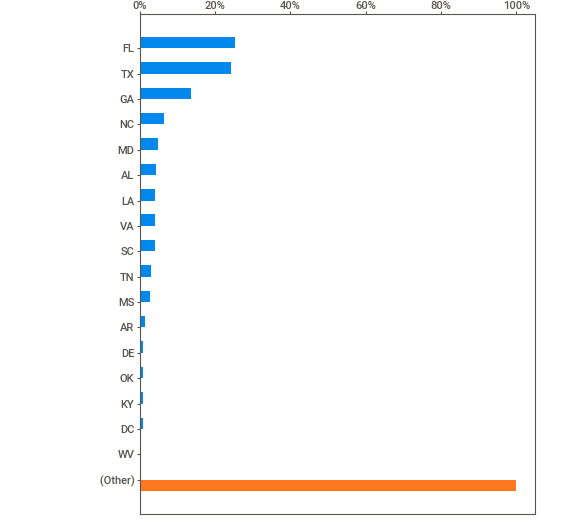
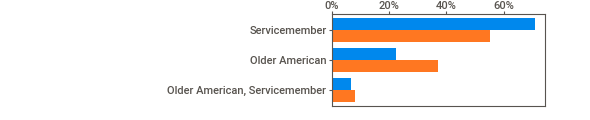
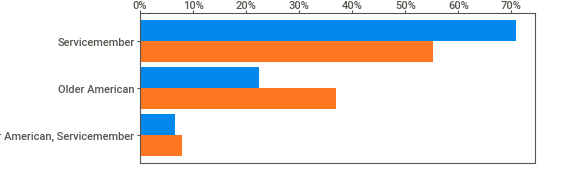
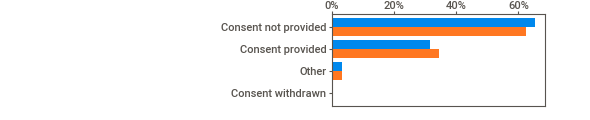
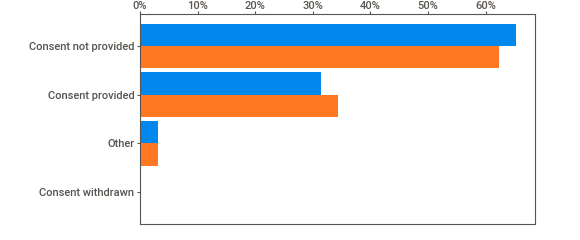
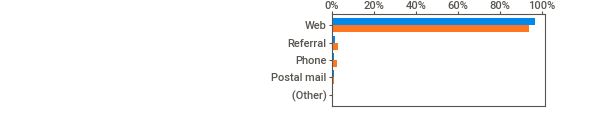
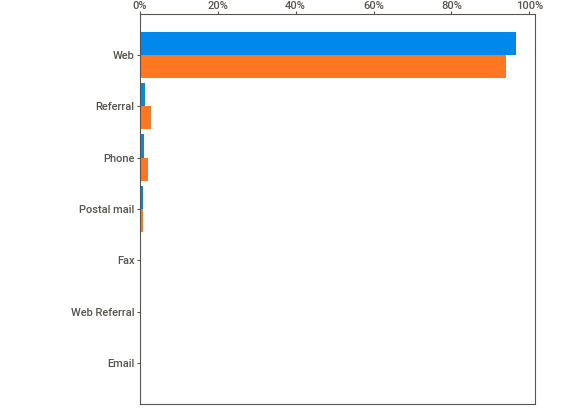
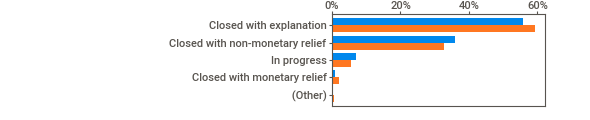
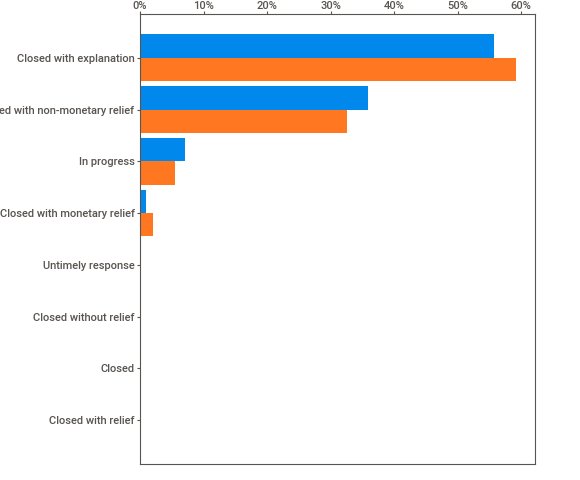
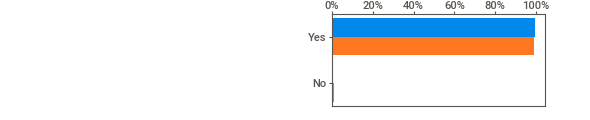
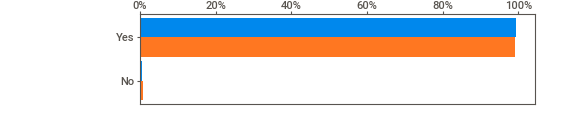
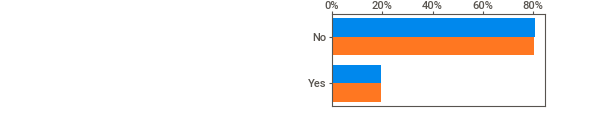
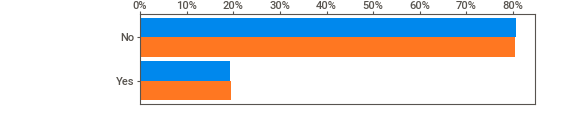
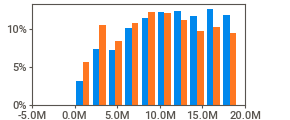
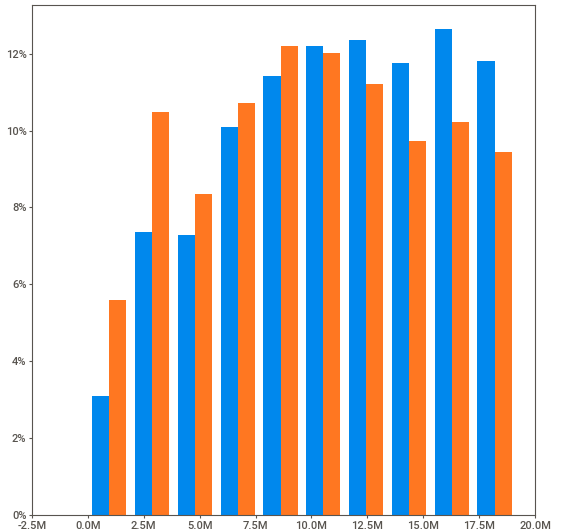
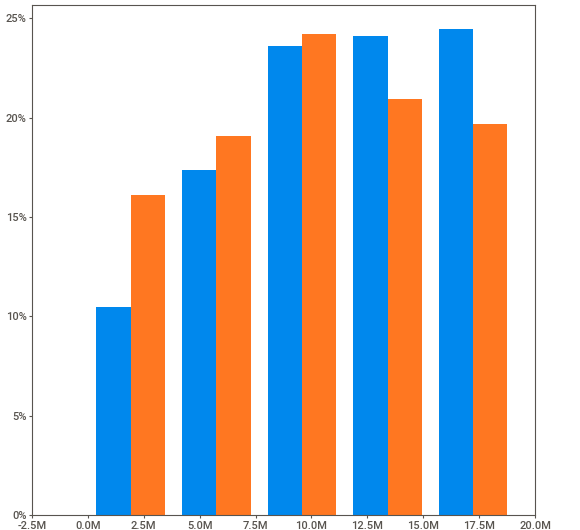
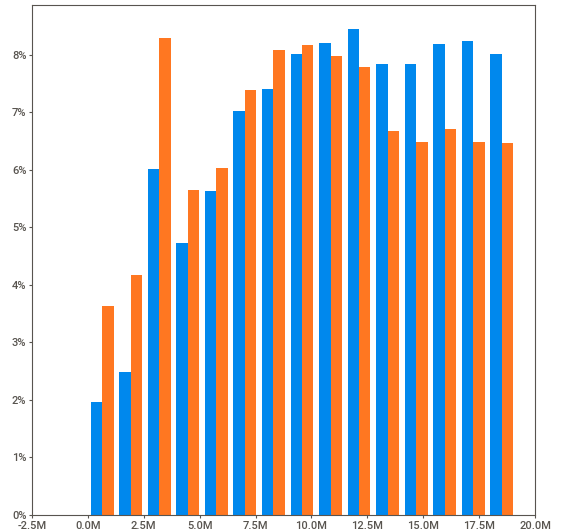
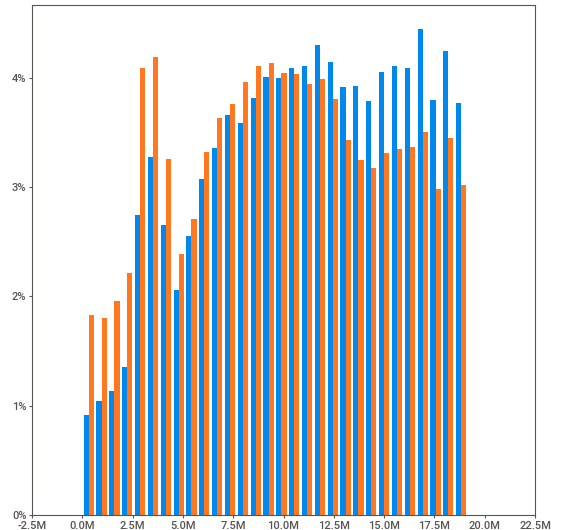
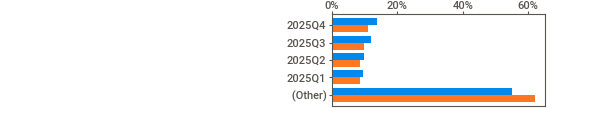
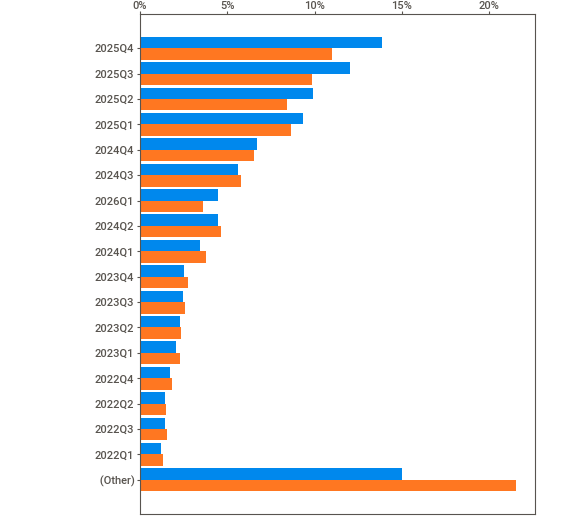
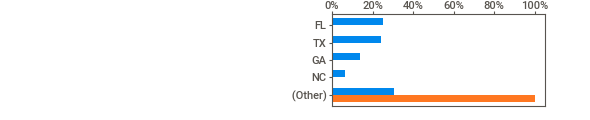
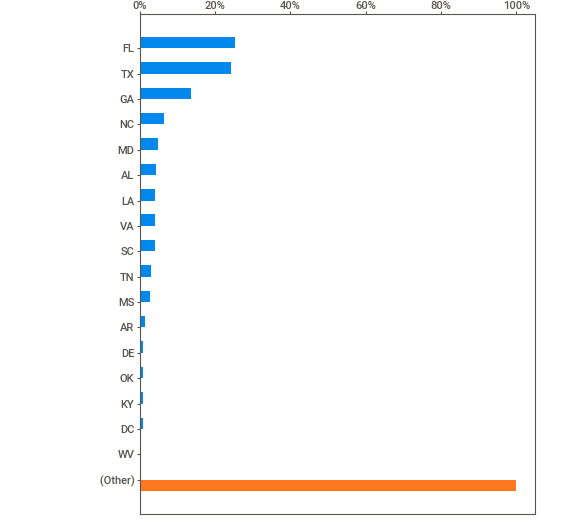
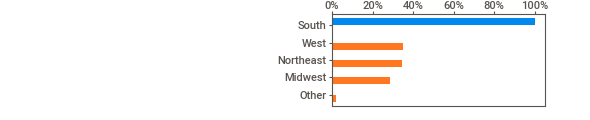
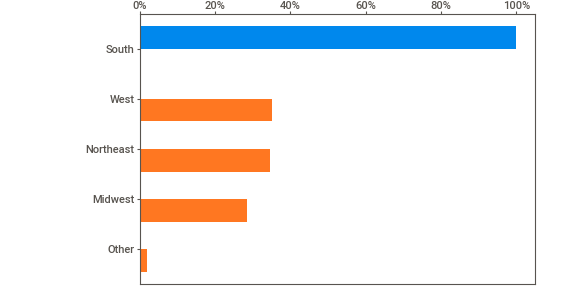
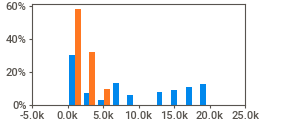
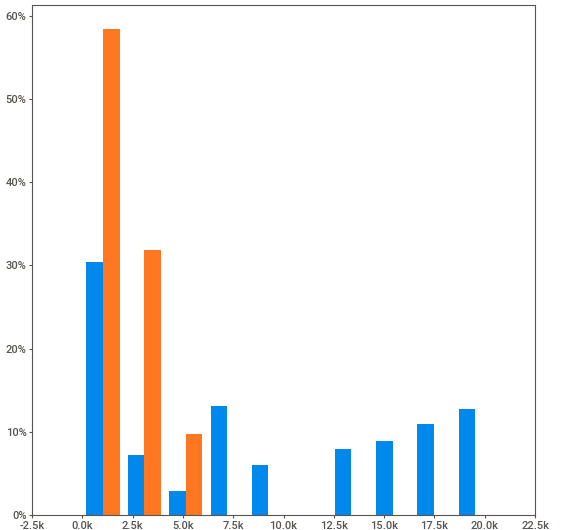
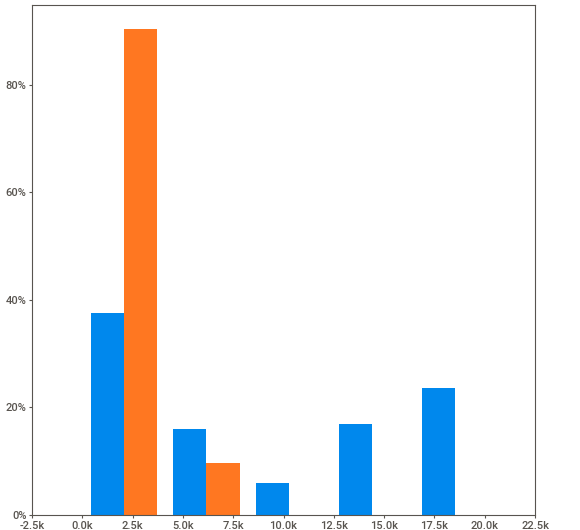
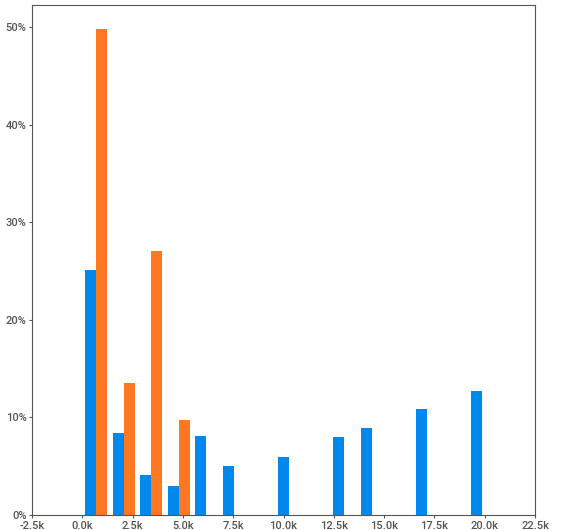
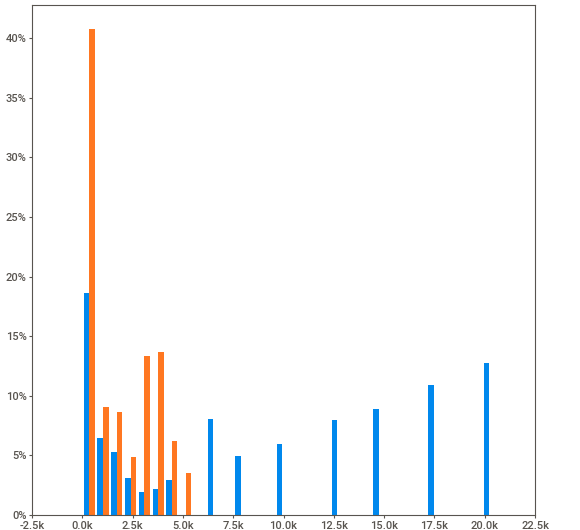
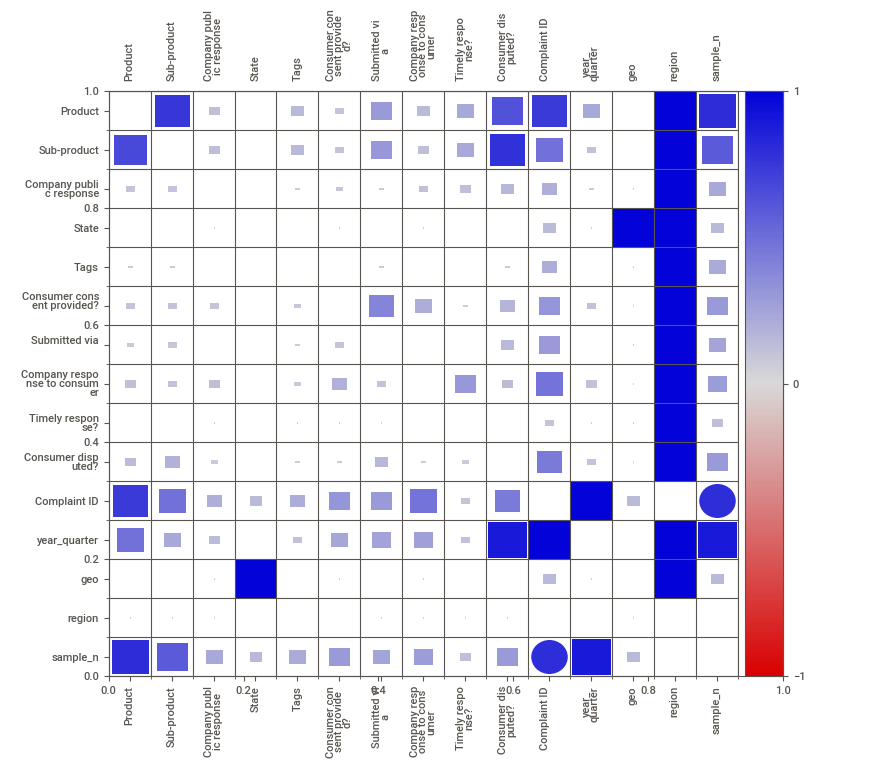
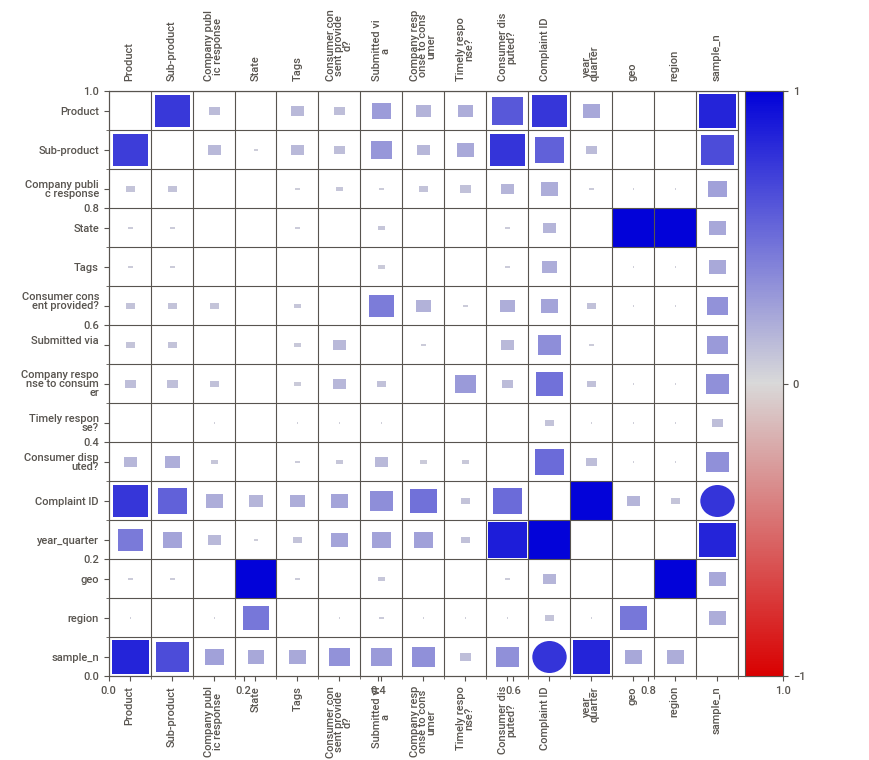

In [ ]:
# Notebook iframe
sweet_report.show_notebook(scale=0.9)

In [ ]:
# Save Sweetviz regional comparison report for Credit Reporting subset
sweet_report.show_html('../reports/credit_reporting_south_vs_others_sweetviz.html')

Report ../reports/south_vs_others_sweetviz.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


### South vs Others: Review Summary

The South segment shows measurable composition differences that are relevant for modeling and policy interpretation.

Key takeaways:
- Debt-collection-related categories are elevated in South relative to Others.
- Geographic concentration is strongest in large Sunbelt states, especially TX and FL.
- Response timeliness remains high overall, but small directional gaps suggest potential operational variation.

Implications for notebooks 03-04:
- Segment-specific behavior supports separate regional evaluation in time-series workflows.
- South-focused monitoring is justified where complaint categories and growth patterns diverge from the rest of the portfolio.
- Findings should be interpreted as descriptive evidence from the full dataset, not causal inference.

---
***Generating CSV Outputs for Subsequent Notebooks***

In [ ]:
# Keep fields relevant for Credit Reporting time-series analysis in downstream notebooks
df_cr_ts = df_cr[["Date received", "region"]]

